# Hyperparameter Tuning – Aktivitätserkennung (Windowssize 100)

Dieses Notebook führt das **Hyperparameter-Tuning** für drei Machine-Learning-Modelle durch, die zur Erkennung von Körperaktivitäten (z. B. Gehen, Laufen, Sitzen) auf Basis von Sensordaten trainiert werden.

Die drei untersuchten Modelle sind:
- **Random Forest** – ein Ensemble aus vielen Entscheidungsbäumen
- **HistGradientBoosting** – ein schnelles Gradient-Boosting-Verfahren
- **SVM (Support Vector Machine)** – ein klassischer Klassifikator mit RBF-Kernel

**Ziel des Tunings:** Für jedes Modell werden automatisch die besten Hyperparameter gesucht, die den **Macro-F1-Score** maximieren. So wird sichergestellt, dass das Modell alle Aktivitätsklassen möglichst gleichmässig gut erkennt – auch wenn manche Klassen seltener vorkommen.

> ⚠️ **WICHTIG:** Dieses Notebook sollte **nicht erneut vollständig ausgeführt** werden, da das Tuning ca. **3 Stunden** dauert. Die besten Hyperparameter wurden bereits als JSON-Dateien gespeichert und können direkt geladen werden.

## 1. Bibliotheken Import

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, ConfusionMatrixDisplay, make_scorer
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from scipy.stats import loguniform, randint
import matplotlib.pyplot as plt
import json
from pathlib import Path
import joblib

### 1.1 Ordnerpfade einlesen

In [2]:
#Pfad von Training und Testdaten
BASE = "..\\..\\..\\Model_data"

#Feature Pfad
out_dir = Path("..\\..\\..\\Model_data\\ML_Daten")
out_dir.mkdir(parents=True, exist_ok=True)

#Features laden und Datensplit vorbereiten
BASE_ML = "..\\..\\..\\Model_data\\ML_Daten"

#Modell Pfad
out_dir_model = Path("..\\..\\..\\Modell\\ML_Modell")
out_dir_model.mkdir(parents=True, exist_ok=True)

#Confusion Matrix Pfad
cm_plot_path = Path("..\\..\\Confusion_Matrix\\ML")
cm_plot_path.mkdir(parents=True, exist_ok=True)

#Performance Plot Pfad
performance_plot_path = Path("..\\..\\PerformancePlots\\ML")
performance_plot_path.mkdir(parents=True, exist_ok=True)


## 2. Rohdaten einlesen

Die Sensordaten wurden in einem früheren Verarbeitungsschritt in die in diesem Notebook behalndelte **Windowssize** aufgeteilt und als `.npz`-Dateien gespeichert. Hier werden die Trainings- und Testdaten geladen.

**Datenstruktur:**
- `X`: 3D-Array der Form `(Anzahl Fenster, Fenstergrösse, Anzahl Kanäle)` – enthält die Zeitreihendaten pro Fenster
- `y`: 1D-Array mit der Aktivitätsklasse (Label) für jedes Fenster

**Kanäle (13 Sensorsignale):**
- `x_acc, y_acc, z_acc` – Beschleunigung in 3 Achsen (Accelerometer)
- `x_gyr, y_gyr, z_gyr` – Winkelgeschwindigkeit in 3 Achsen (Gyroskop)
- `qx, qy, qz, qw` – Quaternionen (Orientierung im Raum)
- `roll, pitch, yaw` – Eulerwinkel (Rotationen um die 3 Achsen)

Die Ausgabe zeigt die Dimensionen der Arrays und die vorhandenen Aktivitätsklassen.

In [3]:
train_data = np.load(f"{BASE}/train_split1_100WS.npz")
X_train_raw = train_data["X"]
y_train_raw = train_data["y"]

test_data = np.load(f"{BASE}/test_split1_100WS.npz")
X_test_raw = test_data["X"]
y_test_raw = test_data["y"]

CHANNEL_NAMES = [
    "x_acc", "y_acc", "z_acc",
    "x_gyr", "y_gyr", "z_gyr",
    "qx", "qy", "qz", "qw",
    "roll", "pitch", "yaw"
]

print(f"X_train: {X_train_raw.shape}  y_train: {y_train_raw.shape}")
print(f"X_test:  {X_test_raw.shape}  y_test:  {y_test_raw.shape}")
print(f"Klassen: {np.unique(y_train_raw)}")

X_train: (21167, 100, 13)  y_train: (21167,)
X_test:  (3969, 100, 13)  y_test:  (3969,)
Klassen: ['Auto' 'Laufen' 'Lift' 'Roundkick' 'Treppe' 'Velo' 'Zug']


## 3. Feature Engineering

Rohe Zeitreihendaten sind für klassische ML-Modelle (Random Forest, SVM etc.) nicht direkt geeignet – diese Modelle erwarten einen **festen Vektor** pro Datenpunkt, keine Zeitreihe.

Deshalb wird aus jedem Sensorfenster ein **Feature-Vektor** berechnet, der die wichtigsten statistischen Eigenschaften kompakt zusammenfasst.

**Berechnete Features pro Kanal (11 Features × 13 Kanäle = 143 Features):**

| Feature | Bedeutung |
|---|---|
| Mittelwert | Durchschnittlicher Signalwert im Fenster |
| Standardabweichung | Streuung / Variabilität des Signals |
| Minimum / Maximum | Extremwerte im Fenster |
| Median | Robuster Zentralwert (weniger empfindlich auf Ausreißer) |
| IQR (Interquartilsabstand) | Spanne der mittleren 50 % der Werte |
| RMS (Root Mean Square) | Effektivwert – Mass für die Signalstärke |
| Range | Differenz zwischen Maximum und Minimum |
| Mittlere abs. Änderung | Durchschnittliche Änderungsrate von Zeitschritt zu Zeitschritt |
| Zero-Crossing-Rate | Wie oft wechselt das Signal sein Vorzeichen (Aktivitätsmass) |
| Steigung (Trend) | Linearer Trend des Signals über das Fenster |

**Zusätzlich (22 Features):** Die gleichen 11 Features werden auch für den **Betrag des Beschleunigungsvektors** (√(x²+y²+z²)) und den **Betrag des Gyroskop-Vektors** berechnet – diese sind richtungsunabhängig und besonders aussagekräftig für Aktivitätserkennung.

**Gesamtanzahl Features pro Fenster:** 13 × 11 + 2 × 11 = **165 Features**
Wichtig ist es, dass man das auch für die Testdaten macht, da diese dieselbe Repräsentation haben müssen.

Nach der Berechnung werden die Feature-Matrizen als `.npz`-Dateien gespeichert, damit dieser Schritt nicht bei jedem Tuning-Lauf wiederholt werden muss.

In [11]:
def feature_engineering(X):
    # Berechnung von Mittelwert, Standardabweichung, Minimum und Maximum, Median, IQR, RMS, Range, 
    # Mittlere absolute Abweichung, Zero-Crossing-Rate, Steigung für jedes Fenster
    features = []
    for window in X:
        feature_vector = []
        for channel in range(window.shape[1]):
            #Mittelwert
            feature_vector.append(np.mean(window[:, channel]))
            #Standardabweichung
            feature_vector.append(np.std(window[:, channel]))
            #Minimum
            feature_vector.append(np.min(window[:, channel]))
            #Maximum
            feature_vector.append(np.max(window[:, channel]))
            #Median
            feature_vector.append(np.median(window[:, channel]))
            #Interquartilsabstand
            feature_vector.append(np.percentile(window[:, channel], 75) - np.percentile(window[:, channel], 25))
            #Root Mean Square
            feature_vector.append(np.sqrt(np.mean(window[:, channel]**2)))
            #Range
            feature_vector.append(np.max(window[:, channel]) - np.min(window[:, channel]))
            #Mittlere absolute Abweichung
            feature_vector.append(np.mean(np.abs(np.diff(window[:, channel]))))
            #Zero-Crossing-Rate
            zentriert = window[:, channel] - np.mean(window[:, channel])
            feature_vector.append(np.sum(np.diff(np.sign(zentriert)) != 0))
            #Steigung
            zeitachse = np.arange(len(window[:, channel]))
            if np.std(window[:, channel]) < 1e-10:
                feature_vector.append(0.0)
            else:
                feature_vector.append(np.polyfit(zeitachse, window[:, channel], 1)[0])
        
        #Vektorbetrag für Accelerometer und Gyroskop
        Accelerometer_vektor_betrag = np.sqrt(window[:, 0]**2 + window[:, 1]**2 + window[:, 2]**2)
        Gyroskop_vektor_betrag = np.sqrt(window[:, 3]**2 + window[:, 4]**2 + window[:, 5]**2)

        # 11 Features für Accelerometer-Betrag
        for betrag in [Accelerometer_vektor_betrag, Gyroskop_vektor_betrag]:
            feature_vector.append(np.mean(betrag))
            feature_vector.append(np.std(betrag))
            feature_vector.append(np.min(betrag))
            feature_vector.append(np.max(betrag))
            feature_vector.append(np.median(betrag))
            feature_vector.append(np.percentile(betrag, 75) - np.percentile(betrag, 25))
            feature_vector.append(np.sqrt(np.mean(betrag**2)))
            feature_vector.append(np.max(betrag) - np.min(betrag))
            feature_vector.append(np.mean(np.abs(np.diff(betrag))))
            zentriert = betrag - np.mean(betrag)
            feature_vector.append(np.sum(np.diff(np.sign(zentriert)) != 0))
            zeitachse = np.arange(len(betrag))
            if np.std(betrag) < 1e-10:
                feature_vector.append(0.0)
            else:
                feature_vector.append(np.polyfit(zeitachse, betrag, 1)[0])


        features.append(feature_vector)
        
    return np.array(features)

In [ ]:
X_train_features = feature_engineering(X_train_raw)
X_test_features  = feature_engineering(X_test_raw)
print(f"Features berechnet:\n Train: {X_train_features.shape}\n Test: {X_test_features.shape}")

Features berechnet: (21167, 165) (3969, 165)


In [ ]:
np.savez_compressed(out_dir / "features_train_100WS.npz", X=X_train_features, y=y_train_raw)
np.savez_compressed(out_dir / "features_test_100WS.npz", X=X_test_features, y=y_test_raw)
print("Gespeichert:", out_dir / "features_train_100WS.npz", out_dir / "features_test_100WS.npz")

Gespeichert: ..\..\..\Model_data\ML_Daten\features_train_100WS.npz ..\..\..\Model_data\ML_Daten\features_test_100WS.npz


## 4. Features laden und Datensplit vorbereiten

Die zuvor berechneten Feature-Vektoren werden hier geladen und für das Training aufbereitet.

**Warum drei Splits (Train / Validation / Test)?**

Um eine faire Modellevaluierung zu gewährleisten, werden die Daten in drei Teile aufgeteilt:

| Split | Anteil | Verwendung |
|---|---|---|
| **Trainingsset** | ~85 % der Trainingsdaten | Zum Anpassen der Modellparameter |
| **Validierungsset** | ~15 % der Trainingsdaten | Zum Überprüfen der Leistung nach dem Tuning |
| **Testset** | separat gespeichert | Finale, unvoreingenommene Bewertung – **nur einmal anschauen!** |

`stratify=y_train_raw` stellt sicher, dass alle Klassen in jedem Split gleich verteilt sind – wichtig bei ungleichmässigen Klassengrössen.

**Label Encoding:** Die Klassen-Labels (z. B. Aktivitätsnamen als Text) werden in Zahlen (0, 1, 2, ...) umgewandelt, da sklearn-Modelle numerische Labels benötigen.

**StandardScaler:** Alle Features werden auf Mittelwert 0 und Standardabweichung 1 normiert. Das ist besonders für die SVM entscheidend (reagiert sehr empfindlich auf unterschiedliche Skalen). Der Scaler wird **nur auf dem Trainingsset** gelernt (`fit_transform`) und dann auf Validierungs- und Testset angewendet (`transform`) – so vermeiden wir Datenlecks (Data Leakage).


In [4]:
train_f = np.load(f"{BASE_ML}/features_train_100WS.npz")
test_f  = np.load(f"{BASE_ML}/features_test_100WS.npz")


X_train_feat = train_f["X"]
y_train_raw = train_f["y"]


X_test_feat = test_f["X"]
y_test_raw = test_f["y"]

#Splitten der Trainingsdaten in Trainings- und Validierungsset
X_train, X_val, y_train, y_val = train_test_split(
    X_train_feat, y_train_raw,
    test_size=0.15,
    stratify=y_train_raw,
    random_state=42
)

le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_val_encoded   = le.transform(y_val)
y_test_encoded  = le.transform(y_test_raw)
class_names = le.classes_

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test_feat)

## 5. Random Forest – Hyperparameter-Tuning

Ein **Random Forest** besteht aus vielen Entscheidungsbäumen, die unabhängig voneinander auf zufälligen Teilmengen der Daten trainiert werden. Die Mehrheitsentscheidung aller Bäume ergibt die finale Klassifikation (Ensemble-Methode).

**Gesuchte Hyperparameter:**

| Parameter | Bedeutung | Suchbereich |
|---|---|---|
| `n_estimators` | Anzahl der Bäume im Wald | 100–800 |
| `max_depth` | Maximale Tiefe jedes Baumes (verhindert Overfitting) | 5–30 |
| `min_samples_leaf` | Mindestanzahl Samples in einem Blatt (Regularisierung) | 1–20 |
| `max_features` | Anteil der Features pro Split (sorgt für Diversität) | sqrt, log2, 30 %, 50 % |
| `class_weight` | Gewichtung der Klassen (wichtig bei Klassenungleichgewicht) | balanced, balanced_subsample |

**Suchmethode – RandomizedSearchCV:**
Statt alle Kombinationen zu testen (Grid Search = sehr langsam), werden **80 zufällige Kombinationen** aus dem Suchraum gezogen und bewertet. Jede Kombination wird mit **5-facher stratifizierter Kreuzvalidierung** getestet – d. h. die Trainingsdaten werden 5-mal in Trainings- und Validierungsanteil aufgeteilt, und der Durchschnitt der Scores bestimmt die Qualität.

**Bewertungsmetrik:** Macro-F1-Score – bewertet jede Klasse gleichwertig, unabhängig von ihrer Häufigkeit.

Die besten Hyperparameter werden am Ende als **JSON-Datei gespeichert**, damit das Tuning nicht nochmals durchgeführt werden muss.

> ⚠️ **Nicht erneut ausführen**, ausser die JSON-Datei ging verloren!

In [ ]:
param_dist = {
    "n_estimators":     randint(100, 800),
    "max_depth":        randint(5, 30),        # oder None erlauben
    "min_samples_leaf": randint(1, 20),
    "max_features":     ["sqrt", "log2", 0.3, 0.5],
    "class_weight":     ["balanced", "balanced_subsample"]
}

base_model = RandomForestClassifier(random_state=42)

folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorer = make_scorer(f1_score, average="macro")
random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=80,
    scoring=scorer,
    cv=folds,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search_f1 = random_search.fit(X_train_scaled, y_train_encoded)
search_params = random_search.best_params_
print("\nBeste Hyperparameter-Kombination:")
for param, value in search_params.items():
    print(f"{param}: {value:.4f}" if isinstance(value, float) else f"{param}: {value}")

payload = {
    "best_params": random_search.best_params_,
    "best_cv_score_macro_f1": float(random_search.best_score_),
}

with open(out_dir_model / "best_hyperparameters_random_forest_100WS.json", "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2, ensure_ascii=False)
print("Gespeichert:", out_dir_model / "best_hyperparameters_random_forest_100WS.json")

Fitting 5 folds for each of 80 candidates, totalling 400 fits

Beste Hyperparameter-Kombination:
class_weight: balanced
max_depth: 26
max_features: sqrt
min_samples_leaf: 2
n_estimators: 443
Gespeichert: ..\..\..\Model_data\ML_Daten\best_hyperparameters_random_forest_100WS.json


### Beste Hyperparameter aus JSON laden

Da das Tuning bereits abgeschlossen ist, werden die besten Hyperparameter direkt aus der gespeicherten JSON-Datei geladen – kein erneutes Training nötig.

Zusätzlich wird der beste **Cross-Validation-Score** (Macro-F1) ausgegeben, den das Modell während des Tunings auf den Trainingsdaten erreicht hat. Dieser gibt an, wie gut das Modell im Durchschnitt über alle 5 Kreuzvalidierungsfaltungen abgeschnitten hat.

In [5]:
with open(out_dir_model / "best_hyperparameters_random_forest_100WS.json", encoding="utf-8") as f:
    hp = json.load(f)
best_params = hp["best_params"]
# optional, falls vorhanden:
cv_score = hp.get("best_cv_score_macro_f1")
print("Train:", X_train_scaled.shape, "Test:", X_test_scaled.shape)
print("Klassen:", list(class_names))
print("best_params geladen:", best_params)
if cv_score is not None:
    print("Bestes CV-Score (macro F1):", cv_score)

Train: (17991, 165) Test: (3969, 165)
Klassen: [np.str_('Auto'), np.str_('Laufen'), np.str_('Lift'), np.str_('Roundkick'), np.str_('Treppe'), np.str_('Velo'), np.str_('Zug')]
best_params geladen: {'class_weight': 'balanced', 'max_depth': 26, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 443}
Bestes CV-Score (macro F1): 0.980886520212602


### Finales Modell trainieren und speichern

Mit den geladenen besten Hyperparametern wird nun das **finale Random-Forest-Modell** auf dem vollständigen Trainingsset trainiert.

**Evaluierungsablauf:**
1. **Validierungsset** – erste Überprüfung der Leistung nach dem Training (darf mehrfach angeschaut werden)
2. **Testset** – die finale, unvoreingenommene Bewertung (**nur einmal!** Mehrmaliges Anschauen würde dazu verleiten, das Modell unbewusst auf das Testset zu optimieren)

Der `classification_report` zeigt **Precision, Recall und F1-Score** pro Klasse sowie über alle Klassen gemittelt.

Anschliessend wird eine **Konfusionsmatrix** als Bild gespeichert. Sie zeigt, welche Aktivitäten das Modell verwechselt: Jede Zeile steht für die echte Klasse, jede Spalte für die vorhergesagte Klasse. Werte auf der Diagonale sind korrekte Vorhersagen.

Zuletzt werden Accuracy, F1-Macro und F1-Weighted als **Balkendiagramm** visualisiert und gespeichert.

**Speicherung als Joblib-Datei:**
Das Modell wird zusammen mit dem Scaler und dem Label-Encoder als `.joblib`-Datei gespeichert, sodass es später direkt für Vorhersagen geladen werden kann – ohne erneutes Training.


In [6]:
best_model = RandomForestClassifier(
    **best_params,
    random_state=42,
    n_jobs=-1)

best_model.fit(X_train_scaled, y_train_encoded)

# Validierungsset
y_val_pred = best_model.predict(X_val_scaled)
print("\nValidation-Set Performance:")
print(classification_report(y_val_encoded, y_val_pred, target_names=class_names))

# Erst danach: Testset (einmalig!)
y_test_pred = best_model.predict(X_test_scaled)
print("\n=== FINALE TEST PERFORMANCE ===")
print(classification_report(y_test_encoded, y_test_pred, target_names=class_names))


artifact = {
    "model": best_model,
    "scaler": scaler,
    "label_encoder": le,
    "class_names": list(class_names),
    "best_params": best_params,
}
out_path = Path(out_dir_model / "final_model_random_forest_100WS.joblib")
joblib.dump(artifact, out_path)
print("Gespeichert:", out_path)


Validation-Set Performance:
              precision    recall  f1-score   support

        Auto       1.00      1.00      1.00       771
      Laufen       0.97      0.99      0.98       626
        Lift       0.99      0.97      0.98       191
   Roundkick       1.00      0.98      0.99        48
      Treppe       0.96      0.88      0.92       101
        Velo       0.99      0.99      0.99       845
         Zug       0.99      0.99      0.99       594

    accuracy                           0.99      3176
   macro avg       0.99      0.97      0.98      3176
weighted avg       0.99      0.99      0.99      3176


=== FINALE TEST PERFORMANCE ===
              precision    recall  f1-score   support

        Auto       0.87      0.96      0.91       974
      Laufen       0.89      0.83      0.86      1109
        Lift       0.87      0.75      0.81       241
   Roundkick       0.96      0.84      0.89       154
      Treppe       0.15      0.14      0.15       180
        Velo    

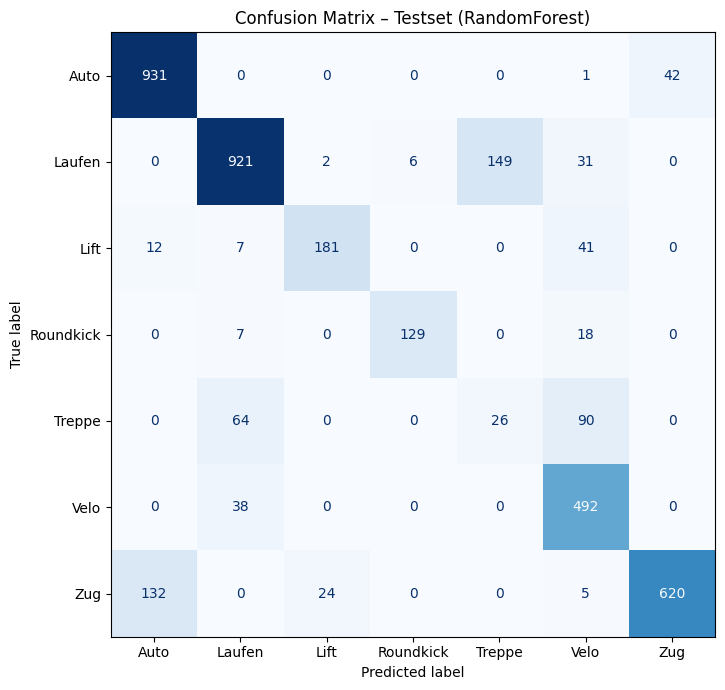

In [7]:
cm = confusion_matrix(y_test_encoded, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix – Testset (RandomForest)")
plt.tight_layout()
#plot speichern
fig.savefig(cm_plot_path / "RandomForest_100WS.png", dpi=300)
plt.show()

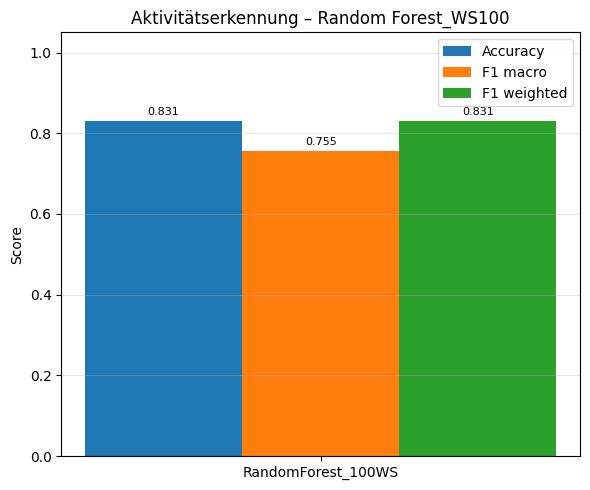

In [8]:
# -----------------------------
# Metriken berechnen
# -----------------------------
rf_accuracy = accuracy_score(
    y_test_encoded,
    y_test_pred
)

rf_f1_macro = f1_score(
    y_test_encoded,
    y_test_pred,
    average="macro"
)

rf_f1_weighted = f1_score(
    y_test_encoded,
    y_test_pred,
    average="weighted"
)

# -----------------------------
# DataFrame
# -----------------------------
summary = pd.DataFrame({
    "Accuracy": [rf_accuracy],
    "F1 macro": [rf_f1_macro],
    "F1 weighted": [rf_f1_weighted],
}, index=["RandomForest_100WS"])


# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 5))

x_pos = np.arange(len(summary))
bar_width = 0.25

ax.bar(
    x_pos - bar_width,
    summary["Accuracy"],
    bar_width,
    label="Accuracy"
)

ax.bar(
    x_pos,
    summary["F1 macro"],
    bar_width,
    label="F1 macro"
)

ax.bar(
    x_pos + bar_width,
    summary["F1 weighted"],
    bar_width,
    label="F1 weighted"
)

ax.set_xticks(x_pos)
ax.set_xticklabels(summary.index)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Aktivitätserkennung – Random Forest_WS100")

ax.legend()
ax.grid(axis="y", alpha=0.3)

# Werte auf Balken
for i, col in enumerate([
    "Accuracy",
    "F1 macro",
    "F1 weighted"
]):
    for j, val in enumerate(summary[col]):
        ax.text(
            j + (i - 1) * bar_width,
            val + 0.01,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()

# Plot speichern (gleiches Muster wie Confusion Matrix)
fig.savefig(
    performance_plot_path / "RandomForest_100WS.png",
    dpi=300
)

plt.show()

## 6. HistGradientBoosting – Hyperparameter-Tuning

**HistGradientBoosting** ist ein modernes, schnelles Gradient-Boosting-Verfahren. Im Gegensatz zum Random Forest werden die Bäume **sequenziell** trainiert: Jeder neue Baum versucht, die Fehler des vorherigen zu korrigieren (Boosting-Prinzip).

Durch die Verwendung von **Histogrammen** (diskretisierte Feature-Werte) ist es deutlich schneller als klassisches Gradient Boosting und skaliert gut bei vielen Datenpunkten.

**Gesuchte Hyperparameter:**

| Parameter | Bedeutung | Suchbereich |
|---|---|---|
| `max_iter` | Anzahl der Boosting-Runden (= Anzahl Bäume) | 100–800 |
| `max_depth` | Maximale Tiefe jedes Baumes | 3–20 |
| `min_samples_leaf` | Mindestanzahl Samples pro Blatt | 1–50 |
| `learning_rate` | Lernrate – wie stark jeder Baum gewichtet wird | 0.01–0.3 (log-verteilt) |
| `l2_regularization` | Regularisierungsstärke gegen Overfitting | 1e-6–10 (log-verteilt) |
| `max_bins` | Auflösung der Histogramme für die Feature-Diskretisierung | 63, 127, 255 |
| `class_weight` | Klassengewichtung | balanced, None |

`loguniform` wird für `learning_rate` und `l2_regularization` verwendet, da diese Parameter über mehrere Grössenordnungen variieren können – eine lineare Verteilung würde kleine Werte stark benachteiligen.

Vorgehen identisch zum Random Forest: 80 zufällige Kombinationen, 5-fache Kreuzvalidierung, Bewertung per Macro-F1.


In [ ]:
param_dist_hgb = {
    "max_iter":        randint(100, 800),
    "max_depth":       randint(3, 20),
    "min_samples_leaf": randint(1, 50),
    "learning_rate":   loguniform(0.01, 0.3),
    "l2_regularization": loguniform(1e-6, 10),
    "max_bins":        [63, 127, 255],
    "class_weight":    ["balanced", None]
}

base_model_hgb = HistGradientBoostingClassifier(random_state=42)

random_search_hgb = RandomizedSearchCV(
    estimator=base_model_hgb,
    param_distributions=param_dist_hgb,
    n_iter=80,
    scoring=scorer,
    cv=folds,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search_hgb = random_search_hgb.fit(X_train_scaled, y_train_encoded)
search_params_hgb = random_search_hgb.best_params_
print("\nBeste Hyperparameter-Kombination (HistGradientBoosting):")
for param, value in search_params_hgb.items():
    print(f"{param}: {value:.4f}" if isinstance(value, float) else f"{param}: {value}")


payload_hgb = {
    "best_params": random_search_hgb.best_params_,
    "best_cv_score_macro_f1": float(random_search_hgb.best_score_),
}

with open(out_dir_model / "best_hyperparameters_hgb_100WS.json", "w", encoding="utf-8") as f:
    json.dump(payload_hgb, f, indent=2, ensure_ascii=False)
print("Gespeichert:", out_dir_model / "best_hyperparameters_hgb_100WS.json")

Fitting 5 folds for each of 80 candidates, totalling 400 fits

Beste Hyperparameter-Kombination (HistGradientBoosting):
class_weight: balanced
l2_regularization: 0.0000
learning_rate: 0.1131
max_bins: 63
max_depth: 7
max_iter: 317
min_samples_leaf: 14
Gespeichert: ..\..\..\Model_data\ML_Daten\best_hyperparameters_hgb_100WS.json


### Beste Hyperparameter aus JSON laden

Gleich wie beim Random Forest: Die gespeicherten besten Hyperparameter für HistGradientBoosting werden aus der JSON-Datei geladen, um das erneute Tuning zu überspringen.


In [9]:
with open(out_dir_model / "best_hyperparameters_hgb_100WS.json", encoding="utf-8") as f:
    hp = json.load(f)
best_params = hp["best_params"]
# optional, falls vorhanden:
cv_score = hp.get("best_cv_score_macro_f1")
print("Train:", X_train_scaled.shape, "Test:", X_test_scaled.shape)
print("Klassen:", list(class_names))
print("best_params geladen:", best_params)
if cv_score is not None:
    print("Bestes CV-Score (macro F1):", cv_score)

Train: (17991, 165) Test: (3969, 165)
Klassen: [np.str_('Auto'), np.str_('Laufen'), np.str_('Lift'), np.str_('Roundkick'), np.str_('Treppe'), np.str_('Velo'), np.str_('Zug')]
best_params geladen: {'class_weight': 'balanced', 'l2_regularization': 6.873211713642722e-06, 'learning_rate': 0.1131225105716033, 'max_bins': 63, 'max_depth': 7, 'max_iter': 317, 'min_samples_leaf': 14}
Bestes CV-Score (macro F1): 0.9896141026652089


### Finales Modell trainieren und speichern

Das finale HistGradientBoosting-Modell wird mit den besten Hyperparametern auf dem Trainingsset trainiert. Anschliessend werden Validation- und Test-Performance ausgegeben (Klassifikationsreport, Konfusionsmatrix, Balkendiagramm) und das Modell als `.joblib`-Datei gespeichert – analog zum Random Forest.


In [10]:
best_model = HistGradientBoostingClassifier(
    **best_params,
    random_state=42)

best_model.fit(X_train_scaled, y_train_encoded)

# Validierungsset
y_val_pred = best_model.predict(X_val_scaled)
print("\nValidation-Set Performance:")
print(classification_report(y_val_encoded, y_val_pred, target_names=class_names))

# Erst danach: Testset (einmalig!)
y_test_pred = best_model.predict(X_test_scaled)
print("\n=== FINALE TEST PERFORMANCE ===")
print(classification_report(y_test_encoded, y_test_pred, target_names=class_names))


artifact = {
    "model": best_model,
    "scaler": scaler,
    "label_encoder": le,
    "class_names": list(class_names),
    "best_params": best_params,
}
out_path = Path(out_dir_model / "final_model_hist_gradient_boosting_100WS.joblib")
joblib.dump(artifact, out_path)
print("Gespeichert:", out_path)


Validation-Set Performance:
              precision    recall  f1-score   support

        Auto       1.00      1.00      1.00       771
      Laufen       0.99      1.00      1.00       626
        Lift       1.00      0.99      0.99       191
   Roundkick       0.98      1.00      0.99        48
      Treppe       0.97      0.97      0.97       101
        Velo       1.00      1.00      1.00       845
         Zug       1.00      1.00      1.00       594

    accuracy                           1.00      3176
   macro avg       0.99      0.99      0.99      3176
weighted avg       1.00      1.00      1.00      3176


=== FINALE TEST PERFORMANCE ===
              precision    recall  f1-score   support

        Auto       0.87      0.97      0.91       974
      Laufen       0.91      0.81      0.86      1109
        Lift       0.66      0.78      0.71       241
   Roundkick       0.93      0.81      0.87       154
      Treppe       0.29      0.36      0.32       180
        Velo    

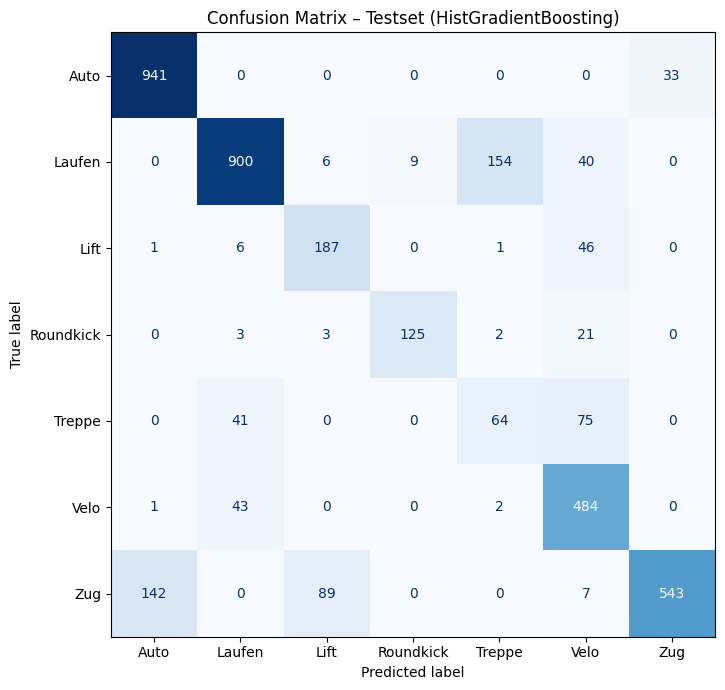

In [11]:
cm = confusion_matrix(y_test_encoded, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix – Testset (HistGradientBoosting)")
plt.tight_layout()
#plot speichern
fig.savefig(cm_plot_path / "HistGradientBoosting_100WS.png", dpi=300)
plt.show()

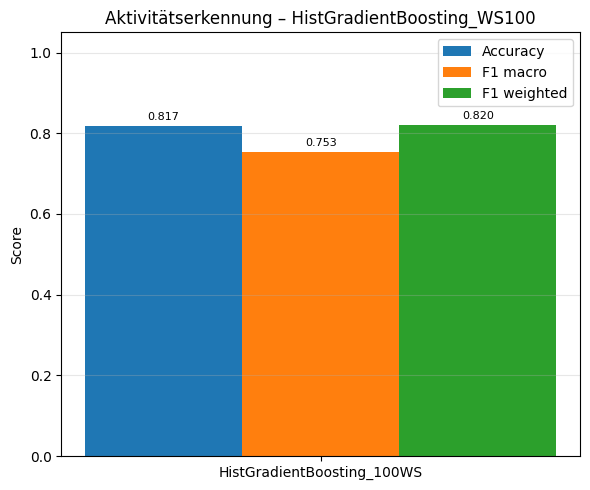

In [12]:
# -----------------------------
# Metriken berechnen
# -----------------------------
rf_accuracy = accuracy_score(
    y_test_encoded,
    y_test_pred
)

rf_f1_macro = f1_score(
    y_test_encoded,
    y_test_pred,
    average="macro"
)

rf_f1_weighted = f1_score(
    y_test_encoded,
    y_test_pred,
    average="weighted"
)

# -----------------------------
# DataFrame
# -----------------------------
summary = pd.DataFrame({
    "Accuracy": [rf_accuracy],
    "F1 macro": [rf_f1_macro],
    "F1 weighted": [rf_f1_weighted],
}, index=["HistGradientBoosting_100WS"])


# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 5))

x_pos = np.arange(len(summary))
bar_width = 0.25

ax.bar(
    x_pos - bar_width,
    summary["Accuracy"],
    bar_width,
    label="Accuracy"
)

ax.bar(
    x_pos,
    summary["F1 macro"],
    bar_width,
    label="F1 macro"
)

ax.bar(
    x_pos + bar_width,
    summary["F1 weighted"],
    bar_width,
    label="F1 weighted"
)

ax.set_xticks(x_pos)
ax.set_xticklabels(summary.index)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Aktivitätserkennung – HistGradientBoosting_WS100")

ax.legend()
ax.grid(axis="y", alpha=0.3)

# Werte auf Balken
for i, col in enumerate([
    "Accuracy",
    "F1 macro",
    "F1 weighted"
]):
    for j, val in enumerate(summary[col]):
        ax.text(
            j + (i - 1) * bar_width,
            val + 0.01,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()

# Plot speichern (gleiches Muster wie Confusion Matrix)
fig.savefig(
    performance_plot_path / "HistGradientBoosting_100WS.png",
    dpi=300
)

plt.show()

## 7. SVM (Support Vector Machine) – Hyperparameter-Tuning

Eine **Support Vector Machine** sucht die Hyperebene im Feature-Raum, die die Klassen mit maximalem Abstand (Margin) trennt. Mit dem **RBF-Kernel (Radial Basis Function)** kann die SVM auch nicht-lineare Entscheidungsgrenzen lernen, indem die Daten implizit in einen höherdimensionalen Raum abgebildet werden.

SVMs reagieren sehr empfindlich auf die Skalierung der Features (deshalb ist der `StandardScaler` aus Schritt 4 besonders wichtig) und auf die Wahl der Hyperparameter `C` und `gamma`.

**Gesuchte Hyperparameter:**

| Parameter | Bedeutung | Suchbereich |
|---|---|---|
| `C` | Regularisierungsstärke – grossen Werte = weniger Toleranz für Fehler, aber Overfitting-Risiko | 0.1–1000 (log-verteilt) |
| `gamma` | Reichweite des RBF-Kernels – kleines gamma = weite Reichweite, grosses gamma = enge Reichweite | 1e-4–1 (log-verteilt) |
| `kernel` | Kernel-Funktion | nur `rbf` |
| `class_weight` | Klassengewichtung | balanced, None |

> **Hinweis:** SVMs können bei grossen Datensätzen deutlich langsamer als Ensemble-Methoden sein, da die Rechenzeit quadratisch mit der Anzahl der Trainingspunkte wächst. Das Tuning kann daher länger dauern als bei Random Forest oder HistGradientBoosting.


In [ ]:
param_dist_svm = {
    "C":           loguniform(0.1, 1000),
    "gamma":       loguniform(1e-4, 1),
    "kernel":      ["rbf"],
    "class_weight": ["balanced", None]
}

base_model_svm = SVC(random_state=42, probability=False)

random_search_svm = RandomizedSearchCV(
    estimator=base_model_svm,
    param_distributions=param_dist_svm,
    n_iter=80,
    scoring=scorer,
    cv=folds,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

search_svm = random_search_svm.fit(X_train_scaled, y_train_encoded)
search_params_svm = random_search_svm.best_params_
print("\nBeste Hyperparameter-Kombination (SVM RBF):")
for param, value in search_params_svm.items():
    print(f"{param}: {value:.4f}" if isinstance(value, float) else f"{param}: {value}")

payload_svm = {
    "best_params": random_search_svm.best_params_,
    "best_cv_score_macro_f1": float(random_search_svm.best_score_),
}

with open(out_dir_model / "best_hyperparameters_svm_rbf_100WS.json", "w", encoding="utf-8") as f:
    json.dump(payload_svm, f, indent=2, ensure_ascii=False)
print("Gespeichert:", out_dir_model / "best_hyperparameters_svm_rbf_100WS.json")

Fitting 5 folds for each of 80 candidates, totalling 400 fits

Beste Hyperparameter-Kombination (SVM RBF):
C: 339.2699
class_weight: balanced
gamma: 0.0023
kernel: rbf
Gespeichert: ..\..\..\Model_data\ML_Daten\best_hyperparameters_svm_rbf_100WS.json


### Beste Hyperparameter aus JSON laden

Gleich wie bei den anderen Modellen: Die besten SVM-Hyperparameter werden aus der JSON-Datei geladen.


In [13]:
with open(out_dir_model / "best_hyperparameters_svm_rbf_100WS.json", encoding="utf-8") as f:
    hp = json.load(f)
best_params = hp["best_params"]
# optional, falls vorhanden:
cv_score = hp.get("best_cv_score_macro_f1")
print("Train:", X_train_scaled.shape, "Test:", X_test_scaled.shape)
print("Klassen:", list(class_names))
print("best_params geladen:", best_params)
if cv_score is not None:
    print("Bestes CV-Score (macro F1):", cv_score)

Train: (17991, 165) Test: (3969, 165)
Klassen: [np.str_('Auto'), np.str_('Laufen'), np.str_('Lift'), np.str_('Roundkick'), np.str_('Treppe'), np.str_('Velo'), np.str_('Zug')]
best_params geladen: {'C': 339.2699327922514, 'class_weight': 'balanced', 'gamma': 0.002270487755790924, 'kernel': 'rbf'}
Bestes CV-Score (macro F1): 0.9772386477565886


### Finales Modell trainieren und speichern

Das finale SVM-Modell wird mit den besten Hyperparametern auf dem Trainingsset trainiert. Anschliessend werden Validation- und Test-Performance ausgegeben und das Modell als `.joblib`-Datei gespeichert – analog zu den anderen Modellen.


In [14]:
best_model = SVC(
    **best_params,
    random_state=42)

best_model.fit(X_train_scaled, y_train_encoded)

# Validierungsset
y_val_pred = best_model.predict(X_val_scaled)
print("\nValidation-Set Performance:")
print(classification_report(y_val_encoded, y_val_pred, target_names=class_names))

# Erst danach: Testset (einmalig!)
y_test_pred = best_model.predict(X_test_scaled)
print("\n=== FINALE TEST PERFORMANCE ===")
print(classification_report(y_test_encoded, y_test_pred, target_names=class_names))


artifact = {
    "model": best_model,
    "scaler": scaler,
    "label_encoder": le,
    "class_names": list(class_names),
    "best_params": best_params,
}
out_path = Path(out_dir_model / "final_model_svm_rbf_100WS.joblib")
joblib.dump(artifact, out_path)
print("Gespeichert:", out_path)


Validation-Set Performance:
              precision    recall  f1-score   support

        Auto       1.00      1.00      1.00       771
      Laufen       0.98      0.99      0.99       626
        Lift       0.93      0.97      0.95       191
   Roundkick       0.96      1.00      0.98        48
      Treppe       0.97      0.92      0.94       101
        Velo       1.00      0.99      1.00       845
         Zug       0.99      0.98      0.99       594

    accuracy                           0.99      3176
   macro avg       0.98      0.98      0.98      3176
weighted avg       0.99      0.99      0.99      3176


=== FINALE TEST PERFORMANCE ===
              precision    recall  f1-score   support

        Auto       0.85      0.70      0.77       974
      Laufen       0.84      0.76      0.80      1109
        Lift       0.54      0.76      0.63       241
   Roundkick       0.95      0.82      0.88       154
      Treppe       0.15      0.23      0.18       180
        Velo    

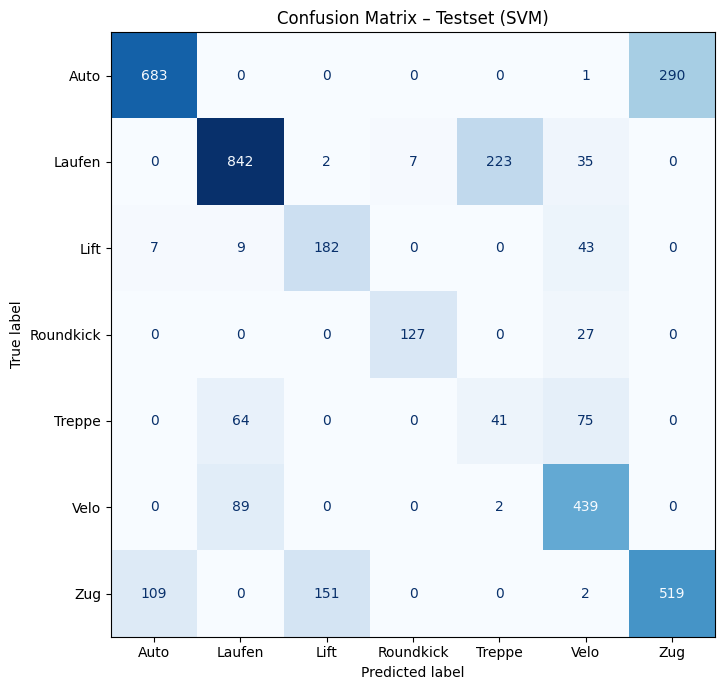

In [15]:
cm = confusion_matrix(y_test_encoded, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(9, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix – Testset (SVM)")
plt.tight_layout()
#plot speichern
fig.savefig(cm_plot_path / "SVM_100WS.png", dpi=300)
plt.show()

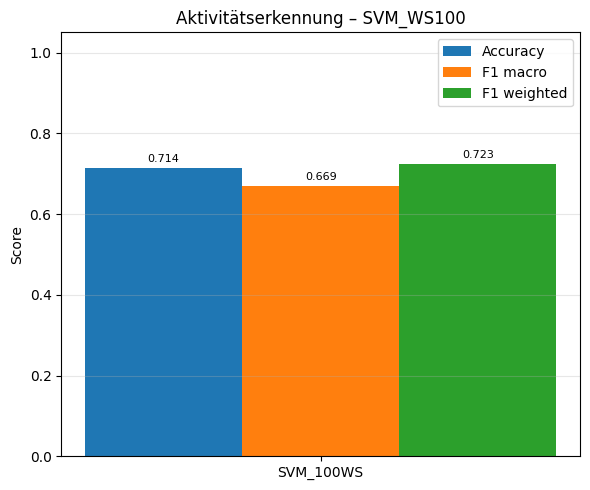

In [16]:
# -----------------------------
# Metriken berechnen
# -----------------------------
rf_accuracy = accuracy_score(
    y_test_encoded,
    y_test_pred
)

rf_f1_macro = f1_score(
    y_test_encoded,
    y_test_pred,
    average="macro"
)

rf_f1_weighted = f1_score(
    y_test_encoded,
    y_test_pred,
    average="weighted"
)

# -----------------------------
# DataFrame
# -----------------------------
summary = pd.DataFrame({
    "Accuracy": [rf_accuracy],
    "F1 macro": [rf_f1_macro],
    "F1 weighted": [rf_f1_weighted],
}, index=["SVM_100WS"])


# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(6, 5))

x_pos = np.arange(len(summary))
bar_width = 0.25

ax.bar(
    x_pos - bar_width,
    summary["Accuracy"],
    bar_width,
    label="Accuracy"
)

ax.bar(
    x_pos,
    summary["F1 macro"],
    bar_width,
    label="F1 macro"
)

ax.bar(
    x_pos + bar_width,
    summary["F1 weighted"],
    bar_width,
    label="F1 weighted"
)

ax.set_xticks(x_pos)
ax.set_xticklabels(summary.index)

ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Aktivitätserkennung – SVM_WS100")

ax.legend()
ax.grid(axis="y", alpha=0.3)

# Werte auf Balken
for i, col in enumerate([
    "Accuracy",
    "F1 macro",
    "F1 weighted"
]):
    for j, val in enumerate(summary[col]):
        ax.text(
            j + (i - 1) * bar_width,
            val + 0.01,
            f"{val:.3f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()

# Plot speichern (gleiches Muster wie Confusion Matrix)
fig.savefig(
    performance_plot_path / "SVM_100WS.png",
    dpi=300
)

plt.show()